# COS30019 Assignment 2B — MAPE vs Test-Set Kurtosis
## Notebook 06: Does traffic volatility explain prediction error?

**Self-contained:** loads saved model weights, recomputes MAPE per approach, then correlates with test-set kurtosis.  
No other notebooks need to be in memory.

---
## 1. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import joblib
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import kurtosis, pearsonr, spearmanr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

LOOKBACK     = 12
HORIZON      = 1
MIN_COVERAGE = 0.5

MODELS_DIR = Path("../models")
DATA_FILE  = Path("../data/processed/scats_wide.parquet")

def make_windows(arr, lookback=LOOKBACK, horizon=HORIZON):
    n = len(arr) - lookback - horizon + 1
    X = np.array([arr[i : i + lookback]                    for i in range(n)])
    y = np.array([arr[i + lookback : i + lookback + horizon] for i in range(n)])
    return X, y

wide_df = pd.read_parquet(DATA_FILE)
print(f"Loaded {wide_df.shape[1]} approaches × {wide_df.shape[0]} timestamps")

Device: cuda
Loaded 139 approaches × 2976 timestamps


---
## 2. Load GRU — Recompute MAPE

In [2]:
GRU_UNITS = 64

class TrafficGRU(nn.Module):
    def __init__(self, gru_units=GRU_UNITS, horizon=HORIZON):
        super().__init__()
        self.gru1  = nn.GRU(input_size=1, hidden_size=gru_units, batch_first=True)
        self.drop1 = nn.Dropout(0.2)
        self.gru2  = nn.GRU(input_size=gru_units, hidden_size=gru_units // 2, batch_first=True)
        self.drop2 = nn.Dropout(0.2)
        self.fc    = nn.Linear(gru_units // 2, horizon)

    def forward(self, x):
        x, _ = self.gru1(x)
        x = self.drop1(x)
        x, _ = self.gru2(x)
        x = self.drop2(x[:, -1, :])
        return self.fc(x)

gru_model = TrafficGRU().to(device)
gru_model.load_state_dict(torch.load(MODELS_DIR / "gru_model.pt", map_location=device))
gru_model.eval()
print("GRU weights loaded")

def torch_predict(model, X_np, batch_size=1024):
    model.eval()
    X_t = torch.FloatTensor(X_np).to(device)
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            preds.append(model(X_t[i:i+batch_size]).cpu().numpy())
    return np.concatenate(preds)

gru_metrics = []
for col in wide_df.columns:
    series = wide_df[col].dropna().values.astype(np.float32)
    if len(series) / len(wide_df) < MIN_COVERAGE:
        continue
    n = len(series)
    val_end  = int(n * 0.85)
    test_raw = series[val_end:]

    scaler   = MinMaxScaler()
    scaler.fit(series[:int(n * 0.70)].reshape(-1, 1))
    test_sc  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    X_c, y_c = make_windows(test_sc)
    if len(X_c) == 0:
        continue

    pred_sc  = torch_predict(gru_model, X_c[..., np.newaxis])
    pred_inv = scaler.inverse_transform(pred_sc).flatten()
    true_inv = scaler.inverse_transform(y_c).flatten()

    mape = np.mean(np.abs((true_inv - pred_inv) / np.where(true_inv == 0, 1, true_inv))) * 100
    gru_metrics.append({"approach": col, "GRU": mape})

gru_df = pd.DataFrame(gru_metrics).set_index("approach")
print(f"GRU MAPE computed for {len(gru_df)} approaches  (mean {gru_df['GRU'].mean():.1f}%)")

GRU weights loaded
GRU MAPE computed for 138 approaches  (mean 33.2%)


---
## 3. Load LSTM — Recompute MAPE

In [3]:
LSTM_UNITS = 64

class TrafficLSTM(nn.Module):
    def __init__(self, lstm_units=LSTM_UNITS, horizon=HORIZON):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=lstm_units, batch_first=True)
        self.drop1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(input_size=lstm_units, hidden_size=lstm_units // 2, batch_first=True)
        self.drop2 = nn.Dropout(0.2)
        self.fc    = nn.Linear(lstm_units // 2, horizon)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.drop1(x)
        x, _ = self.lstm2(x)
        x = self.drop2(x[:, -1, :])
        return self.fc(x)

lstm_model = TrafficLSTM().to(device)
lstm_model.load_state_dict(torch.load(MODELS_DIR / "lstm_model.pt", map_location=device))
lstm_model.eval()
print("LSTM weights loaded")

lstm_metrics = []
for col in wide_df.columns:
    series = wide_df[col].dropna().values.astype(np.float32)
    if len(series) / len(wide_df) < MIN_COVERAGE:
        continue
    n = len(series)
    val_end  = int(n * 0.85)
    test_raw = series[val_end:]

    scaler   = MinMaxScaler()
    scaler.fit(series[:int(n * 0.70)].reshape(-1, 1))
    test_sc  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    X_c, y_c = make_windows(test_sc)
    if len(X_c) == 0:
        continue

    pred_sc  = torch_predict(lstm_model, X_c[..., np.newaxis])
    pred_inv = scaler.inverse_transform(pred_sc).flatten()
    true_inv = scaler.inverse_transform(y_c).flatten()

    mape = np.mean(np.abs((true_inv - pred_inv) / np.where(true_inv == 0, 1, true_inv))) * 100
    lstm_metrics.append({"approach": col, "LSTM": mape})

lstm_df = pd.DataFrame(lstm_metrics).set_index("approach")
print(f"LSTM MAPE computed for {len(lstm_df)} approaches  (mean {lstm_df['LSTM'].mean():.1f}%)")

LSTM weights loaded
LSTM MAPE computed for 138 approaches  (mean 36.2%)


---
## 4. Load XGBoost — Recompute MAPE

In [4]:
xgb_models = joblib.load(MODELS_DIR / "xgboost_model.pkl")
print(f"Loaded {len(xgb_models)} XGBoost models")

def create_features(series, lookback=LOOKBACK):
    df = pd.DataFrame({"target": series})
    for i in range(1, lookback + 1):
        df[f"lag{i}"] = df["target"].shift(i)
    df["hour"]        = df.index.hour
    df["minute"]      = df.index.minute
    df["day_of_week"] = df.index.dayofweek
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
    df = df.dropna()
    return df.drop(columns=["target"]), df["target"]

xgb_metrics = []
for col, model in xgb_models.items():
    series = wide_df[col].dropna()
    X, y   = create_features(series)
    val_end = int(len(X) * 0.85)
    x_test, y_test = X.iloc[val_end:], y.iloc[val_end:]
    if len(x_test) == 0:
        continue
    preds = model.predict(x_test)
    mape  = np.mean(np.abs((y_test.values - preds) / np.where(y_test.values == 0, 1, y_test.values))) * 100
    xgb_metrics.append({"approach": col, "XGBoost": mape})

xgb_df = pd.DataFrame(xgb_metrics).set_index("approach")
print(f"XGBoost MAPE computed for {len(xgb_df)} approaches  (mean {xgb_df['XGBoost'].mean():.1f}%)")

Loaded 139 XGBoost models
XGBoost MAPE computed for 139 approaches  (mean 33.1%)


---
## 5. Compute Test-Set Kurtosis per Approach

In [5]:
records = []
for col in wide_df.columns:
    series   = wide_df[col].dropna().values
    n        = len(series)
    test_raw = series[int(n * 0.85):]
    if len(test_raw) < 4:
        continue
    records.append({
        "approach": col,
        "kurtosis":  kurtosis(test_raw, fisher=True),
        "test_mean": test_raw.mean(),
        "test_std":  test_raw.std(),
    })

kurt_df = pd.DataFrame(records).set_index("approach")
print(kurt_df[["kurtosis", "test_mean", "test_std"]].describe().round(2))

       kurtosis  test_mean  test_std
count    139.00     139.00    139.00
mean      -0.34     105.00     70.82
std        0.99      38.72     24.88
min       -1.44       3.24      3.94
25%       -1.03      79.75     55.79
50%       -0.65      98.81     69.66
75%        0.06     127.77     86.50
max        4.30     259.86    168.86


---
## 6. Combine & Scatter Plot

Approaches with all models: 138


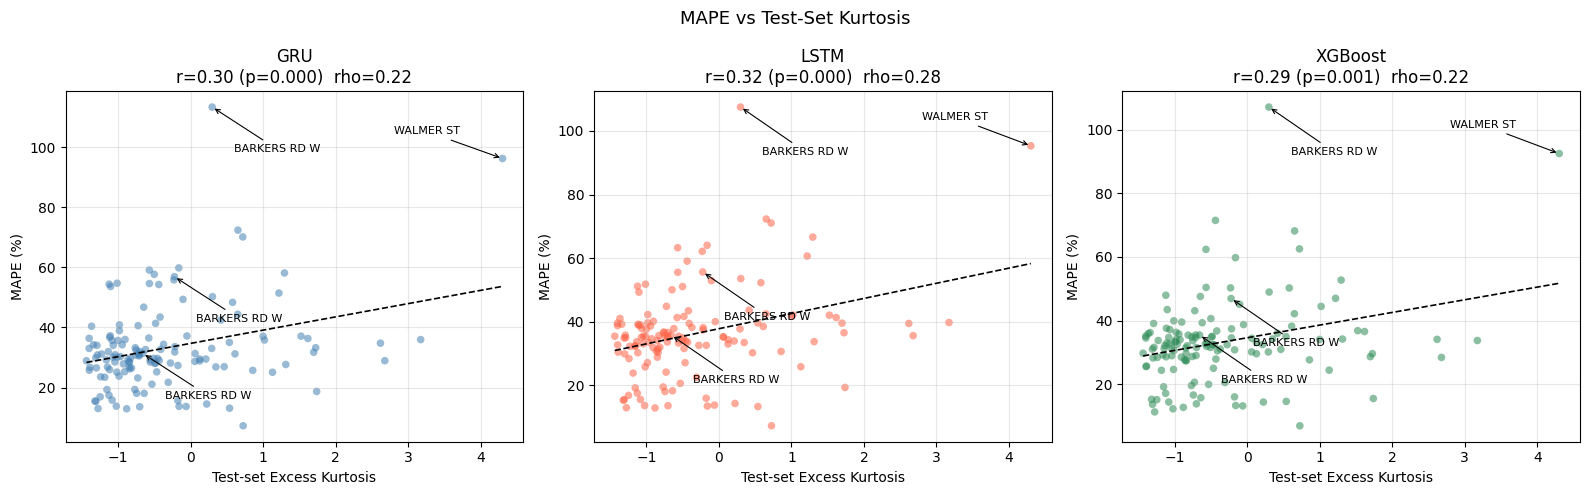

In [6]:
combined = kurt_df.join(gru_df).join(lstm_df).join(xgb_df).dropna()
print(f"Approaches with all models: {len(combined)}")

model_cols = ["GRU", "LSTM", "XGBoost"]
colors     = ["steelblue", "tomato", "seagreen"]

outliers = {
    "WALMER ST":    combined[combined.index.str.contains("WALMER_ST",    case=False)],
    "BARKERS RD W": combined[combined.index.str.contains("BARKERS_RD W", case=False)],
}
kurt_offsets = {
    "WALMER ST":    (-1.5,  8),
    "BARKERS RD W": ( 0.3, -15),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, model, color in zip(axes, model_cols, colors):
    x = combined["kurtosis"]
    y = combined[model]

    ax.scatter(x, y, alpha=0.55, s=30, color=color, edgecolors="none")

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color="black", linewidth=1.2, linestyle="--")

    for label, rows in outliers.items():
        dx, dy = kurt_offsets[label]
        for _, row in rows.iterrows():
            ax.annotate(label, xy=(row["kurtosis"], row[model]),
                        xytext=(row["kurtosis"] + dx, row[model] + dy),
                        arrowprops=dict(arrowstyle="->", color="black", lw=0.8), fontsize=8)

    r, p   = pearsonr(x, y)
    rho, _ = spearmanr(x, y)
    ax.set_title(f"{model}\nr={r:.2f} (p={p:.3f})  rho={rho:.2f}")
    ax.set_xlabel("Test-set Excess Kurtosis")
    ax.set_ylabel("MAPE (%)")
    ax.grid(alpha=0.3)

fig.suptitle("MAPE vs Test-Set Kurtosis", fontsize=13)
fig.tight_layout()
plt.savefig("../data/processed/plot_mape_vs_kurtosis.png", dpi=120)
plt.show()

---
## 7. Correlation Summary

In [7]:
print(f"{'Model':<10} {'Pearson r':>10} {'p-value':>10} {'Spearman ρ':>12} {'p-value':>10}")
print("-" * 55)
for model in model_cols:
    x, y    = combined["kurtosis"], combined[model]
    r,  p   = pearsonr(x, y)
    rho, ps = spearmanr(x, y)
    print(f"{model:<10} {r:>10.3f} {p:>10.4f} {rho:>12.3f} {ps:>10.4f}")

print("\nPositive r → spikier approaches have higher MAPE.")
print("Excess kurtosis = 0 for a normal distribution; higher = heavier tails.")

Model       Pearson r    p-value   Spearman ρ    p-value
-------------------------------------------------------
GRU             0.298     0.0004        0.222     0.0089
LSTM            0.324     0.0001        0.278     0.0009
XGBoost         0.288     0.0006        0.222     0.0090

Positive r → spikier approaches have higher MAPE.
Excess kurtosis = 0 for a normal distribution; higher = heavier tails.


---
## 8. MAPE vs Kurtosis — Coloured by Traffic Volume

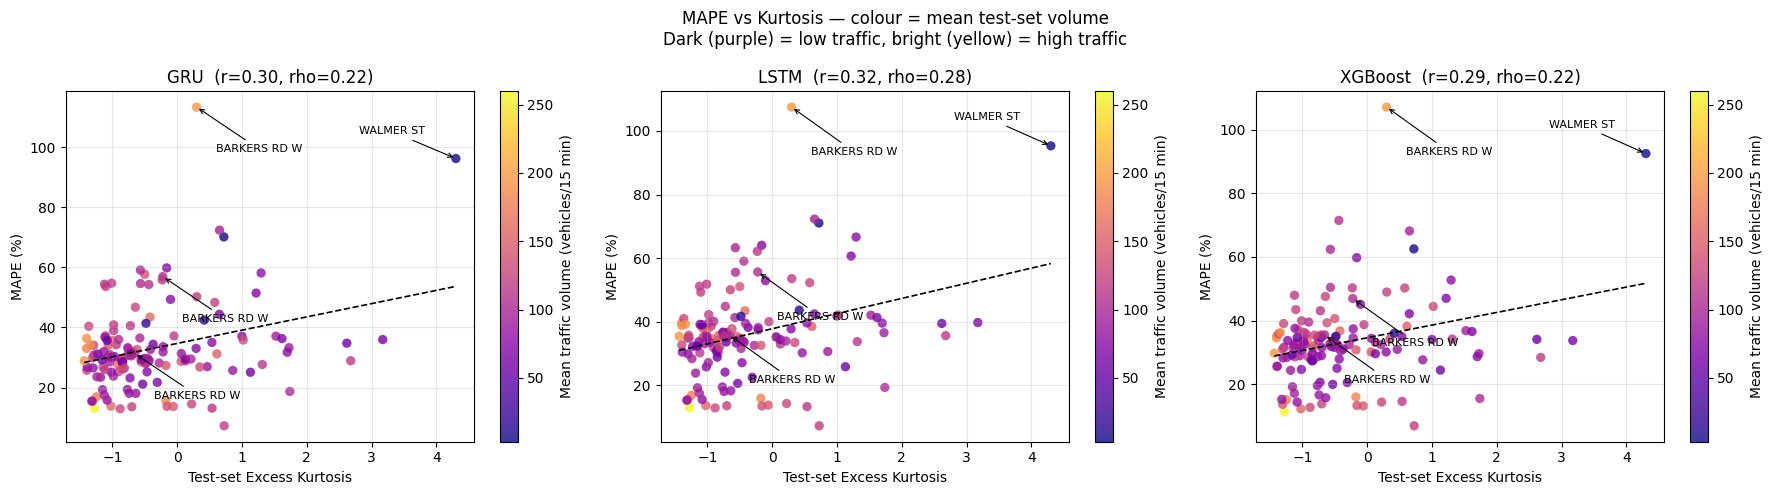

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

volume = combined["test_mean"]
vmin, vmax = volume.min(), volume.max()

for ax, model in zip(axes, model_cols):
    x = combined["kurtosis"]
    y = combined[model]

    sc = ax.scatter(x, y, c=volume, cmap="plasma", vmin=vmin, vmax=vmax,
                    s=45, alpha=0.8, edgecolors="none")

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color="black", linewidth=1.2, linestyle="--")

    for label, rows in outliers.items():
        dx, dy = kurt_offsets[label]
        for _, row in rows.iterrows():
            ax.annotate(label, xy=(row["kurtosis"], row[model]),
                        xytext=(row["kurtosis"] + dx, row[model] + dy),
                        arrowprops=dict(arrowstyle="->", color="black", lw=0.8), fontsize=8)

    r, _   = pearsonr(x, y)
    rho, _ = spearmanr(x, y)
    ax.set_title(f"{model}  (r={r:.2f}, rho={rho:.2f})")
    ax.set_xlabel("Test-set Excess Kurtosis")
    ax.set_ylabel("MAPE (%)")
    ax.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax, label="Mean traffic volume (vehicles/15 min)")

fig.suptitle("MAPE vs Kurtosis — colour = mean test-set volume\nDark (purple) = low traffic, bright (yellow) = high traffic", fontsize=12)
fig.tight_layout()
plt.savefig("../data/processed/plot_mape_vs_kurtosis_volume.png", dpi=120)
plt.show()

---
## 9. Traffic Volume vs MAPE

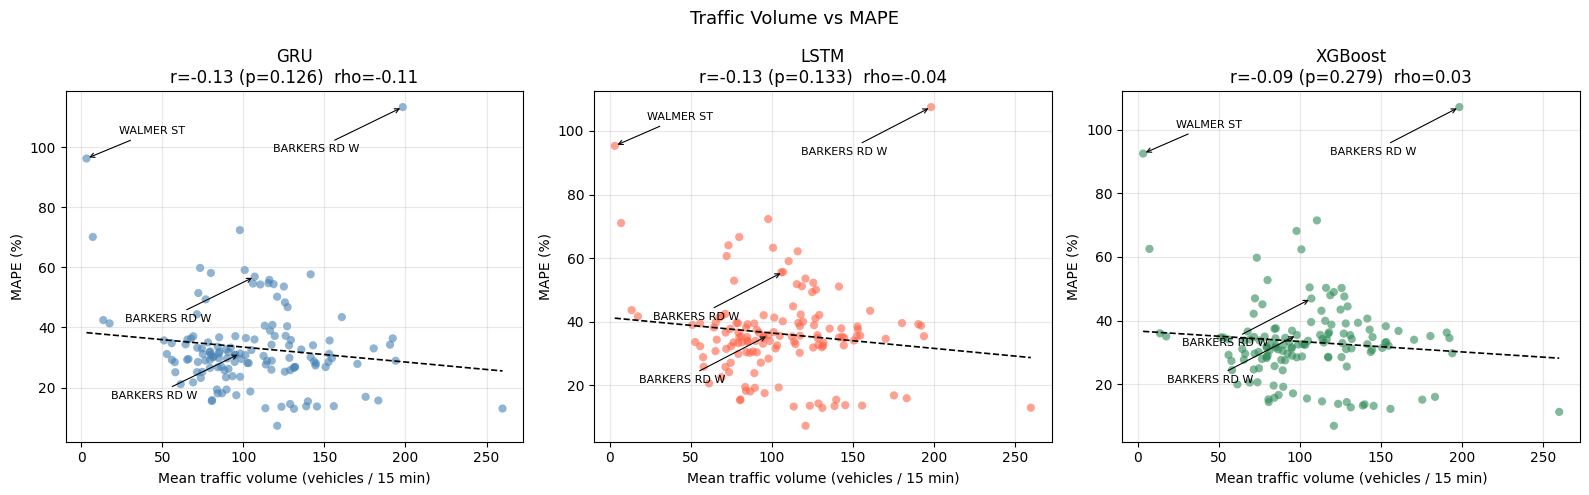


Model       Pearson r    p-value   Spearman rho    p-value
---------------------------------------------------------
GRU            -0.131     0.1260         -0.114     0.1829
LSTM           -0.128     0.1333         -0.036     0.6723
XGBoost        -0.093     0.2792          0.034     0.6946


In [9]:
vol_offsets = {
    "WALMER ST":    ( 20,   8),
    "BARKERS RD W": (-80, -15),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, model, color in zip(axes, model_cols, colors):
    x = combined["test_mean"]
    y = combined[model]

    ax.scatter(x, y, alpha=0.6, s=35, color=color, edgecolors="none")

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color="black", linewidth=1.2, linestyle="--")

    for label, rows in outliers.items():
        dx, dy = vol_offsets[label]
        for _, row in rows.iterrows():
            ax.annotate(label, xy=(row["test_mean"], row[model]),
                        xytext=(row["test_mean"] + dx, row[model] + dy),
                        arrowprops=dict(arrowstyle="->", color="black", lw=0.8), fontsize=8)

    r, p    = pearsonr(x, y)
    rho, ps = spearmanr(x, y)
    ax.set_title(f"{model}\nr={r:.2f} (p={p:.3f})  rho={rho:.2f}")
    ax.set_xlabel("Mean traffic volume (vehicles / 15 min)")
    ax.set_ylabel("MAPE (%)")
    ax.grid(alpha=0.3)

fig.suptitle("Traffic Volume vs MAPE", fontsize=13)
fig.tight_layout()
plt.savefig("../data/processed/plot_volume_vs_mape.png", dpi=120)
plt.show()

print(f"\n{'Model':<10} {'Pearson r':>10} {'p-value':>10} {'Spearman rho':>14} {'p-value':>10}")
print("-" * 57)
for model in model_cols:
    x, y    = combined["test_mean"], combined[model]
    r,  p   = pearsonr(x, y)
    rho, ps = spearmanr(x, y)
    print(f"{model:<10} {r:>10.3f} {p:>10.4f} {rho:>14.3f} {ps:>10.4f}")